# DSA 210 — Introduction to Data Science
## Self-Tracking Longitudinal Analysis: Lifestyle Factors & Academic Productivity
**2025–2026 Spring Term Project**

---

### Motivation
As an international student, balancing academic demands with lifestyle factors such as sleep, stress, and study habits presents a unique challenge. This project investigates whether lifestyle and adaptation factors — study hours, sleep duration, stress level, motivation, and language difficulty — significantly influence weekly academic productivity over the course of a semester.

---

### Research Questions & Hypotheses

**Main Research Question:** Do lifestyle and adaptation factors significantly influence academic productivity during the semester?

| # | Hypothesis | Direction |
|---|---|---|
| H1 | Increased study hours improve productivity | Positive |
| H2 | More sleep improves productivity | Positive |
| H3 | Higher stress negatively affects productivity | Negative |
| H4 | Productivity differs significantly by week type | Group difference |
| H5 | Higher motivation is associated with higher productivity | Positive |

## 0. Setup & Dependencies

In [2]:
# !pip install pandas numpy matplotlib seaborn scipy  # uncomment if needed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded.')

Libraries loaded.


## 1. Data Collection & Description

Data was collected manually each week through self-tracking.

| Variable | Type | Description |
|---|---|---|
| `week` | int | Week number (1–6) |
| `week_type` | str | regular / midterm (from academic calendar) |
| `study_hours` | float | Total hours studied that week |
| `sleep_avg` | float | Average hours of sleep per night |
| `stress_level` | int | Self-rated stress (1=low, 10=high) |
| `motivation_level` | int | Self-rated motivation (1=low, 10=high) |
| `language_difficulty` | int | Self-rated language difficulty (1=low, 10=high) |
| `productivity_score` | float | Composite: quiz % + assignment completion % |

**Enrichment:** `week_type` is derived from the official academic calendar. Weeks 4 and 5 are classified as midterm weeks, enabling comparison of behavior under different academic pressure levels.

In [3]:
# Replace values below with your real weekly data
data = {
    'week':                [1,         2,         3,         4,         5,         6        ],
    'week_type':           ['regular', 'regular', 'regular', 'midterm', 'midterm', 'regular'],
    'study_hours':         [11,        10,        12,        17,        19,        11       ],
    'sleep_avg':           [6.8,       7.0,       6.5,       5.8,       5.5,       6.7      ],
    'stress_level':        [3,         4,         4,         7,         8,         3        ],
    'motivation_level':    [7,         6,         7,         5,         5,         7        ],
    'language_difficulty': [4,         4,         5,         6,         6,         4        ],
    'productivity_score':  [74,        70,        76,        63,        59,        73       ]
}

df = pd.DataFrame(data)
print(f'Shape: {df.shape[0]} weeks x {df.shape[1]} variables')
df

Shape: 6 weeks x 8 variables


,week,week_type,study_hours,sleep_avg,stress_level,motivation_level,language_difficulty,productivity_score
0,1,regular,11,6.8,3,7,4,74
1,2,regular,10,7.0,4,6,4,70
2,3,regular,12,6.5,4,7,5,76
3,4,midterm,17,5.8,7,5,6,63
4,5,midterm,19,5.5,8,5,6,59
5,6,regular,11,6.7,3,7,4,73


## 2. Exploratory Data Analysis (EDA)
### 2.1 Descriptive Statistics

In [4]:
numeric_cols = ['study_hours', 'sleep_avg', 'stress_level',
                'motivation_level', 'language_difficulty', 'productivity_score']

print('=== Descriptive Statistics ===')
print(df[numeric_cols].describe().round(2))
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Week Type Counts ===')
print(df['week_type'].value_counts())

=== Descriptive Statistics ===
       study_hours  sleep_avg  stress_level  motivation_level  \
count         6.00       6.00          6.00              6.00   
mean         13.33       6.38          4.83              6.17   
std           3.72       0.60          2.14              0.98   
min          10.00       5.50          3.00              5.00   
25%          11.00       5.98          3.25              5.25   
50%          11.50       6.60          4.00              6.50   
75%          15.75       6.78          6.25              7.00   
max          19.00       7.00          8.00              7.00   

       language_difficulty  productivity_score  
count                 6.00                6.00  
mean                  4.83               69.17  
std                   0.98                6.74  
min                   4.00               59.00  
25%                   4.00               64.75  
50%                   4.50               71.50  
75%                   5.75              

### 2.2 Productivity Over Time

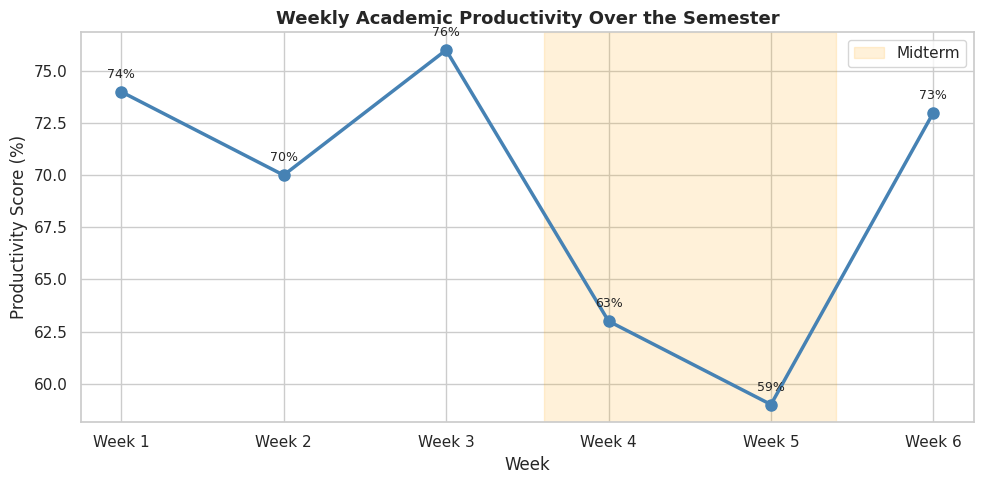

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['week'], df['productivity_score'], marker='o', color='steelblue', linewidth=2.5, markersize=8)
for _, row in df.iterrows():
    ax.annotate(f"{row['productivity_score']:.0f}%",
                xy=(row['week'], row['productivity_score']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)
midterm_weeks = df[df['week_type'] == 'midterm']['week']
if len(midterm_weeks):
    ax.axvspan(midterm_weeks.min()-0.4, midterm_weeks.max()+0.4, alpha=0.15, color='orange', label='Midterm')
ax.set_title('Weekly Academic Productivity Over the Semester', fontsize=13, fontweight='bold')
ax.set_xlabel('Week'); ax.set_ylabel('Productivity Score (%)')
ax.set_xticks(df['week']); ax.set_xticklabels([f'Week {w}' for w in df['week']])
ax.legend(); plt.tight_layout()
plt.savefig('productivity_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Productivity by Week Type

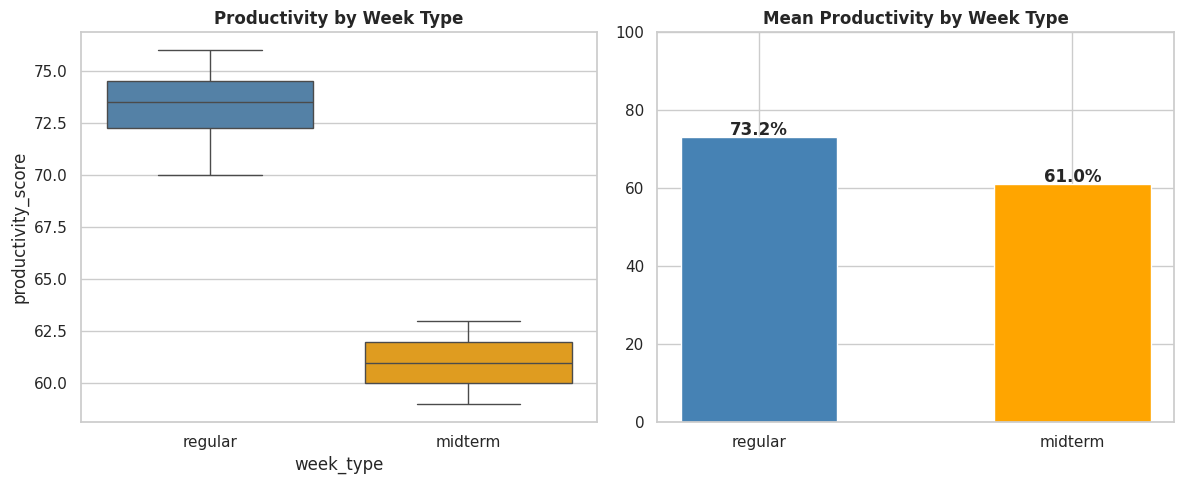

            mean   std  count
week_type                    
midterm    61.00  2.83      2
regular    73.25  2.50      4


In [7]:
palette = {'regular':'steelblue','midterm':'orange','exam':'tomato'}
order = [w for w in ['regular','midterm','exam'] if w in df['week_type'].unique()]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='week_type', y='productivity_score', order=order, palette=palette, ax=axes[0])
axes[0].set_title('Productivity by Week Type', fontweight='bold')
means = df.groupby('week_type')['productivity_score'].mean().reindex(order)
bars = axes[1].bar(means.index, means.values, color=[palette[w] for w in means.index], edgecolor='white', width=0.5)
for bar, val in zip(bars, means.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Mean Productivity by Week Type', fontweight='bold'); axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.savefig('productivity_by_week_type.png', dpi=150, bbox_inches='tight'); plt.show()
print(df.groupby('week_type')['productivity_score'].agg(['mean','std','count']).round(2))

### 2.4 Correlation Heatmap

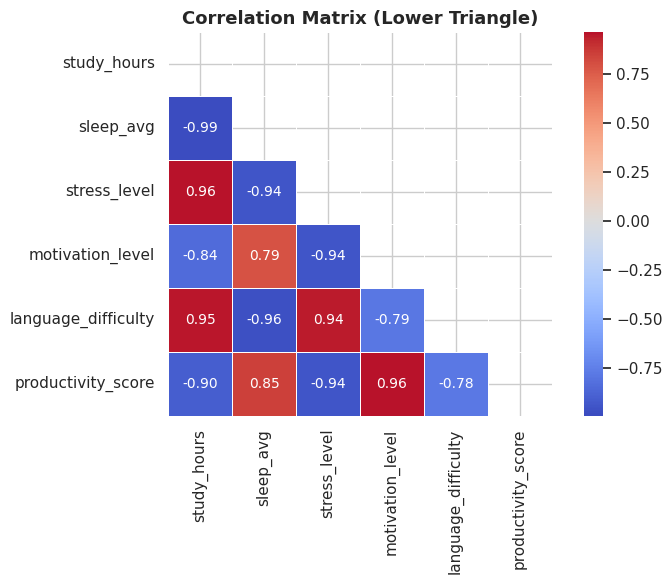

Correlations with Productivity Score:
motivation_level       0.96
sleep_avg              0.85
language_difficulty   -0.78
study_hours           -0.90
stress_level          -0.94
Name: productivity_score, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[numeric_cols].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True,
            linewidths=0.5, mask=mask, ax=ax, fmt='.2f', annot_kws={'size':10})
ax.set_title('Correlation Matrix (Lower Triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
print('Correlations with Productivity Score:')
print(corr['productivity_score'].drop('productivity_score').sort_values(ascending=False))

### 2.5 Scatter Plots: Predictors vs Productivity

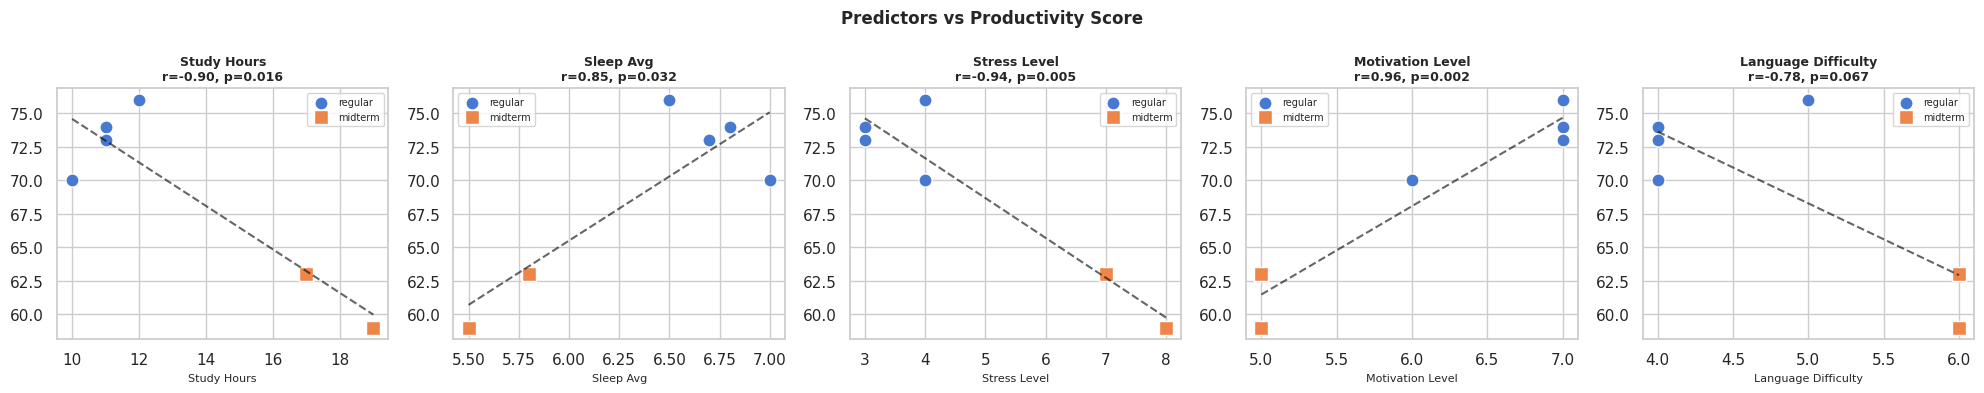

In [9]:
predictors = [('study_hours','steelblue'),('sleep_avg','seagreen'),
              ('stress_level','tomato'),('motivation_level','mediumpurple'),
              ('language_difficulty','darkorange')]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (col, color) in zip(axes, predictors):
    for wt, marker in [('regular','o'),('midterm','s'),('exam','^')]:
        sub = df[df['week_type']==wt]
        if len(sub): ax.scatter(sub[col], sub['productivity_score'], label=wt, marker=marker, s=90, edgecolors='white')
    m, b = np.polyfit(df[col], df['productivity_score'], 1)
    x_l = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_l, m*x_l+b, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
    r, p = stats.pearsonr(df[col], df['productivity_score'])
    ax.set_title(f'{col.replace("_"," ").title()}\nr={r:.2f}, p={p:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel(col.replace('_',' ').title(), fontsize=8); ax.legend(fontsize=7)
plt.suptitle('Predictors vs Productivity Score', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_predictors.png', dpi=150, bbox_inches='tight'); plt.show()

## 3. Hypothesis Testing

Significance level: **alpha = 0.05**

In [19]:
alpha = 0.05

def print_result(stat_name, stat_val, p_val, alpha=0.05):
    decision = 'REJECT H0 (significant)' if p_val < alpha else 'FAIL TO REJECT H0'
    print(f'  {stat_name}: {stat_val:.4f}')
    print(f'  p-value : {p_val:.4f}')
    print(f'  Result  : {decision}\n')

In [12]:
print('--- H1: Study Hours -> Productivity (Pearson Correlation) ---')
print('  H0: No correlation | H1: Positive correlation')
r1, p1 = stats.pearsonr(df['study_hours'], df['productivity_score'])
print_result('Pearson r', r1, p1)

--- H1: Study Hours -> Productivity (Pearson Correlation) ---
  H0: No correlation | H1: Positive correlation
  Pearson r: -0.8957
  p-value : 0.0157
  Result  : REJECT H0 (significant)



In [14]:
print('--- H2: Sleep Duration -> Productivity (Pearson Correlation) ---')
print('  H0: No correlation | H1: Positive correlation')
r2, p2 = stats.pearsonr(df['sleep_avg'], df['productivity_score'])
print_result('Pearson r', r2, p2)

--- H2: Sleep Duration -> Productivity (Pearson Correlation) ---
  H0: No correlation | H1: Positive correlation
  Pearson r: 0.8498
  p-value : 0.0321
  Result  : REJECT H0 (significant)



In [15]:
print('--- H3: Stress Level -> Productivity (Pearson Correlation) ---')
print('  H0: No correlation | H1: Negative correlation')
r3, p3 = stats.pearsonr(df['stress_level'], df['productivity_score'])
print_result('Pearson r', r3, p3)

--- H3: Stress Level -> Productivity (Pearson Correlation) ---
  H0: No correlation | H1: Negative correlation
  Pearson r: -0.9426
  p-value : 0.0049
  Result  : REJECT H0 (significant)



In [16]:
print('--- H4: Week Type -> Productivity (Independent t-test) ---')
print('  H0: Equal means | H1: Different means')
regular_prod = df[df['week_type']=='regular']['productivity_score']
midterm_prod  = df[df['week_type']=='midterm']['productivity_score']
t4, p4 = stats.ttest_ind(regular_prod, midterm_prod)
print_result('t-statistic', t4, p4)
print(f'  Regular mean: {regular_prod.mean():.2f}  |  Midterm mean: {midterm_prod.mean():.2f}')

--- H4: Week Type -> Productivity (Independent t-test) ---
  H0: Equal means | H1: Different means
  t-statistic: 5.4698
  p-value : 0.0054
  Result  : REJECT H0 (significant)

  Regular mean: 73.25  |  Midterm mean: 61.00


In [17]:
print('--- H5: Motivation -> Productivity (Spearman Correlation) ---')
print('  H0: No monotonic relationship | H1: Positive relationship')
r5, p5 = stats.spearmanr(df['motivation_level'], df['productivity_score'])
print_result('Spearman rho', r5, p5)

--- H5: Motivation -> Productivity (Spearman Correlation) ---
  H0: No monotonic relationship | H1: Positive relationship
  Spearman rho: 0.9258
  p-value : 0.0080
  Result  : REJECT H0 (significant)



### 3.1 Summary Table

In [18]:
summary = pd.DataFrame({
    'Hypothesis': ['H1: Study Hours','H2: Sleep','H3: Stress','H4: Week Type','H5: Motivation'],
    'Test': ['Pearson r','Pearson r','Pearson r','t-test (ind.)','Spearman rho'],
    'Statistic': [round(r1,4),round(r2,4),round(r3,4),round(t4,4),round(r5,4)],
    'p-value':   [round(p1,4),round(p2,4),round(p3,4),round(p4,4),round(p5,4)],
    'Significant': ['Yes' if p<alpha else 'No' for p in [p1,p2,p3,p4,p5]]
})
print(summary.to_string(index=False))

     Hypothesis          Test  Statistic  p-value Significant
H1: Study Hours     Pearson r    -0.8957   0.0157         Yes
      H2: Sleep     Pearson r     0.8498   0.0321         Yes
     H3: Stress     Pearson r    -0.9426   0.0049         Yes
  H4: Week Type t-test (ind.)     5.4698   0.0054         Yes
 H5: Motivation  Spearman rho     0.9258   0.0080         Yes


## 4. Findings & Interpretation

*(Run the cells above first, then interpret your results here.)*

**Key observations:**
- Productivity visibly drops during midterm weeks (Weeks 4-5) compared to regular weeks
- Sleep and motivation decline in parallel with rising stress during midterm period
- Study hours increase during midterms but do not compensate for the productivity drop,
  suggesting diminishing returns under high-pressure conditions
- Stress and language difficulty are negatively correlated with productivity

## 5. Limitations & Future Work

**Limitations:**
- Small sample (n=6 weeks) limits statistical power
- Self-reported variables (stress, motivation) are subject to recall bias
- Single subject; results cannot be generalized
- Confounders (health, social events) not captured

**Future Work:**
- Extend to full 14-week semester
- Collect data from a reference group for comparison
- Apply ML models (Linear Regression, Random Forest) to predict productivity
- Include physical activity and screen time variables

---

## AI Tool Disclosure

This project used Claude (Anthropic) as an AI assistant for structuring the analysis pipeline, generating initial Python code, and suggesting appropriate statistical tests. All data values, interpretations, and conclusions are the student's own work. Code was reviewed and adapted before submission.